# 04 — Chiến lược xử lý mất cân bằng

**Mục tiêu.** Đây là **trọng tâm của đề tài**: bảng 20 tổ hợp `5 chiến lược × 4 mô hình`, chạy
cùng một cách chia fold, cùng một cách chọn ngưỡng, để phần so sánh có nghĩa. Báo cáo ghi lại
**mọi** dòng, kể cả cấu hình cho kết quả kém — cái đáng giá là bức tranh so sánh, không phải
riêng mô hình thắng cuộc (US-10, FR-05).

**Việc tương ứng:** T-20 … T-23 trong [TASKS.md](../TASKS.md).

| | Chiến lược | Cấu hình |
|---|---|---|
| S1 | không xử lý | — (mốc tham chiếu, chính là giai đoạn 2) |
| S2 | trọng số lớp | `class_weight='balanced'`, riêng boosting dùng `scale_pos_weight` |
| S3 | giảm mẫu ngẫu nhiên | `RandomUnderSampler(sampling_strategy=0.1)` |
| S4 | SMOTE | `SMOTE(sampling_strategy=0.1, k_neighbors=5)` |
| S5 | SMOTE + Tomek | `SMOTETomek(sampling_strategy=0.1)` |

| | Mô hình | Cấu hình khởi điểm |
|---|---|---|
| M1 | Logistic Regression | `max_iter=1000, solver='liblinear'` |
| M2 | Decision Tree | `max_depth=6` |
| M3 | Random Forest | `n_estimators=300` |
| M4 | XGBoost | `n_estimators=500, learning_rate=0.05, max_depth=6` |

> ## ⏱ Cảnh báo thời gian
>
> TASKS.md ghi 1–3 giờ. Số đo thực tế trên máy này thấp hơn: chạy thử cả 20 tổ hợp mất
> **1,1 phút trên 12.000 dòng** và **3,8 phút trên 48.000 dòng**, tức thời gian tỷ lệ gần như
> tuyến tính theo số dòng (số mũ ≈ 1,06–1,09). Ngoại suy tới 226.980 dòng của tập huấn luyện
> cho **khoảng 20–40 phút**. Cứ giữ 1–3 giờ làm chặn trên cho máy yếu hơn.
>
> Hai điều đã chuẩn bị sẵn cho tình huống chạy lâu:
>
> * **Có điểm lưu.** Sau *mỗi* tổ hợp, bảng được ghi vào `reports/grid_results.csv` và điểm
>   out-of-fold vào `reports/grid_results.npz`. Kernel chết giữa chừng thì chạy lại đúng ô đó,
>   nó sẽ bỏ qua phần đã xong và chạy tiếp.
> * **Có phương án rút gọn.** Nếu vượt 3 giờ, đặt `CHE_DO_NHANH = True` ở ô cấu hình, hạ
>   `n_estimators` xuống 100 cho hai mô hình ensemble. Notebook tự ghi lựa chọn đó vào bảng
>   kết quả để báo cáo nêu rõ (T-20).

**Sản phẩm bàn giao.** `reports/grid_results.csv` (20 dòng) và `reports/grid_results.npz`
(điểm out-of-fold của cả 20 tổ hợp, để mục 3 vẽ đường PR mà không phải huấn luyện lại).

In [1]:
import sys
import time
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src import plots
from src.config import (
    DEFAULT_COST_FN,
    DEFAULT_COST_FP,
    RANDOM_STATE,
    REPORTS_DIR,
    TARGET,
)
from src.data import load_prepared, split_data
from src.evaluate import baseline_pr_auc
from src.features import build_features
from src.modeling import (
    DEFAULT_MODELS,
    DEFAULT_STRATEGIES,
    SAMPLING_STRATEGY,
    imbalance_ratio,
    make_cv,
    run_grid,
)

%matplotlib inline
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

np.random.seed(RANDOM_STATE)

# ---- Cấu hình chạy -------------------------------------------------------
# Bật khi lưới vượt 3 giờ. Phương án dự phòng này đã ghi sẵn trong T-20; bật lên
# thì PHẢI nêu rõ trong báo cáo, vì con số không so trực tiếp được với cấu hình gốc.
CHE_DO_NHANH = False

THAM_SO_RUT_GON = {"random_forest": {"n_estimators": 100},
                   "xgboost": {"n_estimators": 100}}
model_params = THAM_SO_RUT_GON if CHE_DO_NHANH else None

DUONG_DAN_LUOI = REPORTS_DIR / "grid_results.csv"
print("chế độ:", "RÚT GỌN (n_estimators=100)" if CHE_DO_NHANH else "đầy đủ theo 04 §3.2")

chế độ: đầy đủ theo 04 §3.2


---
## 1. Dữ liệu và cách chia fold

Lưới chạy **chỉ trên tập huấn luyện**. Tập kiểm thử không được đụng tới ở giai đoạn này: nó
dành cho lần đánh giá cuối cùng sau khi đã chốt mô hình (ML-06). Mọi con số trong bảng 20 dòng
là **out-of-fold trên tập huấn luyện**, không phải điểm trên tập kiểm thử.

Cách chia tập lặp lại y hệt notebook 03 (`random_state=42`), nên hai notebook nói về cùng một
tập huấn luyện.

In [2]:
df, bao_cao = load_prepared()

X_train_tho, X_test_tho, y_train, y_test = split_data(df, as_features=False)
X_train = build_features(X_train_tho)

# Phần dữ liệu mà lưới nhìn thấy — dùng để quy đổi số cảnh báo mỗi ngày cho đúng.
# Tập huấn luyện là 80% của một cửa sổ hai ngày, không phải 20% như tập kiểm thử.
PHAN_DU_LIEU = len(y_train) / len(df)

print()
print(f"Tập huấn luyện : {len(y_train):,} dòng, {int(y_train.sum())} gian lận "
      f"({y_train.mean():.4%})")
print(f"Tập kiểm thử   : {len(y_test):,} dòng — KHÔNG đụng tới trong notebook này")
print(f"Phần dữ liệu   : {PHAN_DU_LIEU:.1%} của toàn bộ")
print(f"Tỷ lệ mất cân bằng (scale_pos_weight) : {imbalance_ratio(y_train):.1f}")
print(f"Đường cơ sở PR-AUC trên tập huấn luyện: {baseline_pr_auc(y_train):.5f}")

cv = make_cv(random_state=RANDOM_STATE)
print(f"\nCross-validation: StratifiedKFold({cv.get_n_splits()}, shuffle=True, "
      f"random_state={RANDOM_STATE})")
for i, (_, test_idx) in enumerate(cv.split(X_train, y_train), start=1):
    print(f"  fold {i}: {len(test_idx):,} dòng, {int(y_train.iloc[test_idx].sum())} gian lận")

Số dòng        : 284,807
Số cột         : 31
Ô thiếu giá trị: 0
Dòng trùng lặp : 1,081
Gian lận       : 492 (0.173%)
Không phát hiện vấn đề.


Loại 1,081 dòng trùng lặp (0.380%), trong đó 19 mẫu gian lận. Còn lại 283,726 dòng.



Tập huấn luyện : 226,980 dòng, 378 gian lận (0.1665%)
Tập kiểm thử   : 56,746 dòng — KHÔNG đụng tới trong notebook này
Phần dữ liệu   : 80.0% của toàn bộ
Tỷ lệ mất cân bằng (scale_pos_weight) : 599.5
Đường cơ sở PR-AUC trên tập huấn luyện: 0.00167

Cross-validation: StratifiedKFold(5, shuffle=True, random_state=42)
  fold 1: 45,396 dòng, 75 gian lận
  fold 2: 45,396 dòng, 75 gian lận
  fold 3: 45,396 dòng, 76 gian lận
  fold 4: 45,396 dòng, 76 gian lận
  fold 5: 45,396 dòng, 76 gian lận


**Vì sao `sampling_strategy=0.1` chứ không phải 1:1.**

Đưa lớp thiểu số lên ngang lớp đa số nghe hợp lý nhưng làm méo **xác suất tiên nghiệm** rất
mạnh: mô hình học trên dữ liệu 50% gian lận sẽ trả xác suất cao một cách có hệ thống, và khi
gặp luồng thật 0,17% thì precision sụp. Tỷ lệ 0,1 (khoảng 1:10) là điểm khởi đầu mà
[04 §3.1](../docs/04-thiet-ke-mo-hinh-ml.md) chọn, và lựa chọn này phải nêu trong báo cáo.

**Vì sao bước lấy mẫu lại bắt buộc nằm trong pipeline.** Đây là lỗi rò rỉ phổ biến nhất ở bài
toán này: nếu SMOTE chạy trước khi chia fold, mẫu tổng hợp nội suy từ điểm validation lọt vào
tập huấn luyện và mọi chỉ số vọt lên khoảng 0,99. `build_pipeline()` luôn trả pipeline của
**imblearn**, thứ duy nhất tự động bỏ qua bước lấy mẫu khi transform tập validation (ML-01,
TC-20). `tests/test_no_leakage.py` canh đúng điều đó.

In [3]:
print(f"sampling_strategy = {SAMPLING_STRATEGY} → sau khi lấy mẫu lại, mỗi fold huấn luyện có "
      f"khoảng {SAMPLING_STRATEGY:.0%} mẫu dương so với mẫu âm")

n_am_fold = int(len(y_train) * 0.8 * (1 - y_train.mean()))
n_duong_fold = int(y_train.sum() * 0.8)
print()
print(f"Trong một fold huấn luyện (4/5 tập train): khoảng {n_am_fold:,} âm / {n_duong_fold} dương")
print(f"  S3 giảm mẫu   → giữ {n_duong_fold} dương, hạ lớp âm xuống khoảng "
      f"{int(n_duong_fold / SAMPLING_STRATEGY):,} (vứt đi {1 - n_duong_fold / SAMPLING_STRATEGY / n_am_fold:.1%} lớp âm)")
print(f"  S4 SMOTE      → giữ nguyên lớp âm, sinh thêm dương lên khoảng "
      f"{int(n_am_fold * SAMPLING_STRATEGY):,}")

sampling_strategy = 0.1 → sau khi lấy mẫu lại, mỗi fold huấn luyện có khoảng 10% mẫu dương so với mẫu âm

Trong một fold huấn luyện (4/5 tập train): khoảng 181,281 âm / 302 dương
  S3 giảm mẫu   → giữ 302 dương, hạ lớp âm xuống khoảng 3,020 (vứt đi 98.3% lớp âm)
  S4 SMOTE      → giữ nguyên lớp âm, sinh thêm dương lên khoảng 18,128


---
## 2. Chạy lưới 20 tổ hợp — T-20

Mỗi tổ hợp huấn luyện **một lượt** `cross_val_predict` 5 fold. Từ điểm out-of-fold suy ra tất
cả phần còn lại: PR-AUC/ROC-AUC theo từng fold (để có độ lệch chuẩn), ngưỡng τ\* cực tiểu chi
phí, rồi recall/precision/F1 tại τ\* đó.

**τ\* chọn trên chính điểm out-of-fold, không đụng tập kiểm thử** (ML-08). Đây là điểm khiến
cột Recall@τ\* trong bảng dưới trung thực: nếu dò ngưỡng trên tập kiểm thử rồi báo cáo chỉ số
cũng trên tập đó thì mọi con số lạc quan hơn thực tế.

Chi phí giả định: `cost_fn = 122,21` USD, `cost_fp = 5,00` USD ([04 §6.2](../docs/04-thiet-ke-mo-hinh-ml.md)).

In [4]:
bat_dau = time.perf_counter()

bang, diem_oof = run_grid(
    X_train,
    y_train,
    models=DEFAULT_MODELS,
    strategies=DEFAULT_STRATEGIES,
    model_params=model_params,
    cv=cv,
    criterion="min_expected_cost",
    cost_fn=DEFAULT_COST_FN,
    cost_fp=DEFAULT_COST_FP,
    sample_fraction=PHAN_DU_LIEU,
    random_state=RANDOM_STATE,
    checkpoint_path=DUONG_DAN_LUOI,   # ghi lại sau mỗi tổ hợp, chạy lại thì nối tiếp
    return_scores=True,
    verbose=True,
)

tong_thoi_gian = time.perf_counter() - bat_dau
print(f"\n=== toàn bộ lưới: {tong_thoi_gian / 60:.1f} phút ===")

Nối tiếp từ điểm lưu: đã có 20/20 tổ hợp.


=== toàn bộ lưới: 0.0 phút ===


In [5]:
bang["che_do"] = "rút gọn" if CHE_DO_NHANH else "đầy đủ"
bang.to_csv(DUONG_DAN_LUOI, index=False, encoding="utf-8")

doc_lai = pd.read_csv(DUONG_DAN_LUOI)
assert len(doc_lai) == 20, f"T-20 cần đúng 20 dòng, đang có {len(doc_lai)}"
assert set(doc_lai["model"]) == set(DEFAULT_MODELS)
assert set(doc_lai["strategy"]) == set(DEFAULT_STRATEGIES)
assert doc_lai[["model", "strategy"]].duplicated().sum() == 0, "có tổ hợp lặp lại"
assert doc_lai[["pr_auc_mean", "recall", "precision"]].notna().all().all()

print(f"đã ghi {DUONG_DAN_LUOI.relative_to(ROOT)} — {len(doc_lai)} dòng × {doc_lai.shape[1]} cột")
print(f"đã ghi {DUONG_DAN_LUOI.with_suffix('.npz').relative_to(ROOT)} — "
      f"điểm out-of-fold của {len(diem_oof)} tổ hợp "
      f"({DUONG_DAN_LUOI.with_suffix('.npz').stat().st_size / 1024**2:.1f} MB)")
print()
print("T-20 đạt: grid_results.csv có đúng 20 dòng.")

đã ghi reports\grid_results.csv — 20 dòng × 19 cột
đã ghi reports\grid_results.npz — điểm out-of-fold của 20 tổ hợp (13.5 MB)

T-20 đạt: grid_results.csv có đúng 20 dòng.


---
## 3. Bảng 20 tổ hợp — bảng trung tâm của báo cáo

Định dạng theo [04 §3.3](../docs/04-thiet-ke-mo-hinh-ml.md). Cột `n_distinct_scores` không có
trong đặc tả gốc nhưng được thêm vào sau phát hiện ở notebook 03: mô hình phát ra càng ít điểm
rủi ro khác nhau thì càng ít chỗ để tối ưu ngưỡng ở giai đoạn 5.

In [6]:
cot_hien = ["model", "strategy", "pr_auc_mean", "pr_auc_std", "roc_auc_mean",
            "threshold", "recall", "precision", "f1", "alerts_per_day",
            "n_distinct_scores", "total_seconds"]

display(bang[cot_hien].style
        .format({"pr_auc_mean": "{:.4f}", "pr_auc_std": "±{:.4f}", "roc_auc_mean": "{:.4f}",
                 "threshold": "{:.4f}", "recall": "{:.3f}", "precision": "{:.3f}",
                 "f1": "{:.3f}", "alerts_per_day": "{:,.0f}", "total_seconds": "{:.0f}s"})
        .background_gradient(subset=["pr_auc_mean"], cmap="Greens")
        .background_gradient(subset=["total_seconds"], cmap="Oranges"))

,model,strategy,pr_auc_mean,pr_auc_std,roc_auc_mean,threshold,recall,precision,f1,alerts_per_day,n_distinct_scores,total_seconds
0,xgboost,class_weight,0.8549,±0.0301,0.9824,0.0232,0.852,0.702,0.769,287,221674,36s
1,random_forest,smote,0.8549,±0.0311,0.9755,0.1900,0.854,0.666,0.749,303,219,368s
2,random_forest,smote_tomek,0.8549,±0.0311,0.9755,0.1900,0.854,0.666,0.749,303,219,652s
3,xgboost,smote,0.8529,±0.0297,0.9801,0.0336,0.852,0.638,0.729,316,222236,45s
4,xgboost,smote_tomek,0.8529,±0.0297,0.9801,0.0336,0.852,0.638,0.729,316,222236,326s
5,xgboost,none,0.8514,±0.0302,0.9831,0.0468,0.841,0.866,0.854,229,221544,33s
6,random_forest,none,0.8406,±0.0333,0.9533,0.0767,0.852,0.687,0.760,293,207,398s
7,random_forest,class_weight,0.8404,±0.0285,0.9695,0.1233,0.852,0.711,0.775,283,200,159s
8,xgboost,undersample,0.7811,±0.0691,0.9815,0.8684,0.836,0.688,0.755,287,221912,5s
9,random_forest,undersample,0.7586,±0.0446,0.9758,0.5859,0.852,0.697,0.767,289,269,6s


WindowsPath('D:/WorkSpace/AI_Project/fraud-detection/reports/figures/04_grid_heatmap.png')

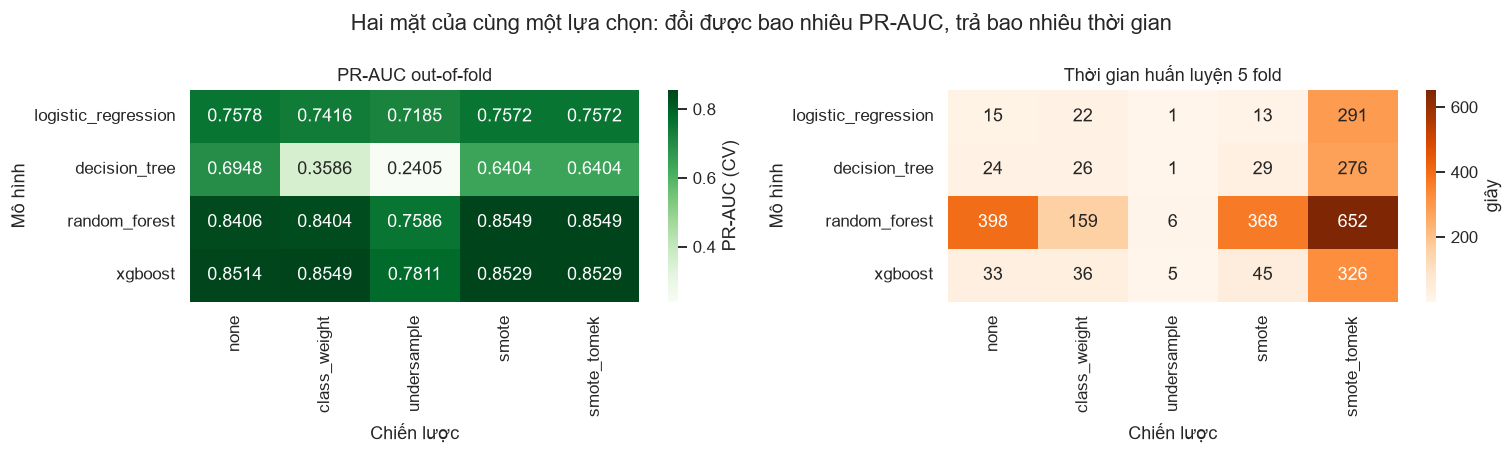

In [7]:
# Ma trận mô hình × chiến lược — dạng dễ đọc nhất để thấy cái gì ăn thua với cái gì
ma_tran = bang.pivot(index="model", columns="strategy", values="pr_auc_mean")
ma_tran = ma_tran.reindex(index=list(DEFAULT_MODELS), columns=list(DEFAULT_STRATEGIES))

fig, truc = plt.subplots(1, 2, figsize=(14, 4.2))

sns.heatmap(ma_tran, annot=True, fmt=".4f", cmap="Greens", ax=truc[0],
            cbar_kws={"label": "PR-AUC (CV)"})
truc[0].set_xlabel("Chiến lược")
truc[0].set_ylabel("Mô hình")
truc[0].set_title("PR-AUC out-of-fold")

ma_tran_gio = bang.pivot(index="model", columns="strategy", values="total_seconds")
ma_tran_gio = ma_tran_gio.reindex(index=list(DEFAULT_MODELS), columns=list(DEFAULT_STRATEGIES))
sns.heatmap(ma_tran_gio, annot=True, fmt=".0f", cmap="Oranges", ax=truc[1],
            cbar_kws={"label": "giây"})
truc[1].set_xlabel("Chiến lược")
truc[1].set_ylabel("Mô hình")
truc[1].set_title("Thời gian huấn luyện 5 fold")

fig.suptitle("Hai mặt của cùng một lựa chọn: đổi được bao nhiêu PR-AUC, trả bao nhiêu thời gian")
fig.tight_layout()
plots.save_fig(fig, "04_grid_heatmap.png")

In [8]:
print("Chiến lược nào thắng, xét trung bình trên 4 mô hình:")
theo_chien_luoc = (bang.groupby("strategy")
                   .agg(pr_auc_trung_binh=("pr_auc_mean", "mean"),
                        pr_auc_tot_nhat=("pr_auc_mean", "max"),
                        recall_trung_binh=("recall", "mean"),
                        precision_trung_binh=("precision", "mean"),
                        giay_tong=("total_seconds", "sum"))
                   .sort_values("pr_auc_trung_binh", ascending=False))
display(theo_chien_luoc.round(4))

print("\nMô hình nào thắng, xét trung bình trên 5 chiến lược:")
theo_mo_hinh = (bang.groupby("model")
                .agg(pr_auc_trung_binh=("pr_auc_mean", "mean"),
                     pr_auc_tot_nhat=("pr_auc_mean", "max"),
                     diem_khac_nhau=("n_distinct_scores", "max"),
                     giay_tong=("total_seconds", "sum"))
                .sort_values("pr_auc_trung_binh", ascending=False))
display(theo_mo_hinh.round(4))

tot_nhat = bang.iloc[0]
print(f"\nTổ hợp tốt nhất: {tot_nhat['model']} + {tot_nhat['strategy']} "
      f"→ PR-AUC {tot_nhat['pr_auc_mean']:.4f} ± {tot_nhat['pr_auc_std']:.4f}")

Chiến lược nào thắng, xét trung bình trên 4 mô hình:


,pr_auc_trung_binh,pr_auc_tot_nhat,recall_trung_binh,precision_trung_binh,giay_tong
strategy,,,,,
none,0.7861,0.8514,0.8320,0.7450,471.2407
smote_tomek,0.7764,0.8549,0.8459,0.6296,1544.0001
smote,0.7764,0.8549,0.8459,0.6296,454.7551
class_weight,0.6989,0.8549,0.8393,0.5714,242.4388
undersample,0.6247,0.7811,0.8459,0.5163,13.5640



Mô hình nào thắng, xét trung bình trên 5 chiến lược:


,pr_auc_trung_binh,pr_auc_tot_nhat,diem_khac_nhau,giay_tong
model,,,,
xgboost,0.8387,0.8549,222236,445.1482
random_forest,0.8299,0.8549,269,1583.5096
logistic_regression,0.7465,0.7578,226318,342.0943
decision_tree,0.5150,0.6948,97,355.2467



Tổ hợp tốt nhất: xgboost + class_weight → PR-AUC 0.8549 ± 0.0301


---
## 4. Đường PR của 5 chiến lược, chồng lên nhau — T-21

Vẽ cho **mô hình tốt nhất** ở bảng trên. Năm đường dùng chung điểm out-of-fold đã có, không
huấn luyện lại lần nào.

Đường cơ sở là tỷ lệ lớp dương của tập huấn luyện — khoảng **0,00167**. Vạch này bắt buộc phải
có mặt: nó là thứ biến con số "PR-AUC 0,82" thành "tốt hơn ngẫu nhiên gần 500 lần".

C:\Users\ACER\AppData\Local\Temp\ipykernel_19664\1725543700.py:23: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()


Đường cơ sở trên hình: 0.00167
T-21 đạt: hình có đường cơ sở 0,00167.


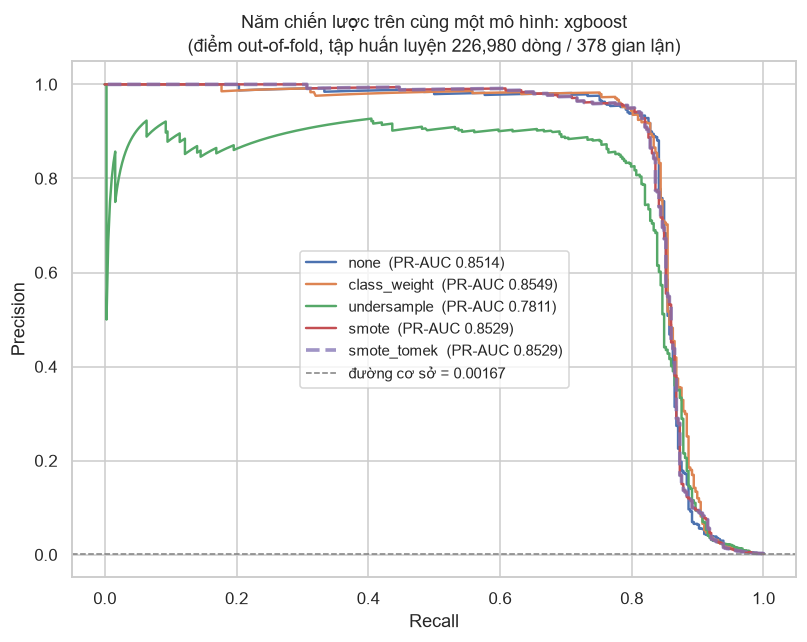

In [9]:
mo_hinh_tot = tot_nhat["model"]

duong_pr = {
    f"{chien_luoc}  (PR-AUC {bang.loc[(bang['model'] == mo_hinh_tot) & (bang['strategy'] == chien_luoc), 'pr_auc_mean'].iloc[0]:.4f})":
        diem_oof[f"{mo_hinh_tot}__{chien_luoc}"]
    for chien_luoc in DEFAULT_STRATEGIES
}

fig, ax = plt.subplots(figsize=(7.5, 6))
plots.plot_pr_curves(duong_pr, y_true=y_train, ax=ax)

# SMOTE+Tomek rất có thể trùng khít SMOTE (xem mục 5). Vẽ nó bằng nét đứt để đường
# nằm dưới vẫn nhìn thấy được — nếu không, người đọc tưởng hình bị thiếu một đường.
for duong in ax.lines:
    if duong.get_label().startswith("smote_tomek"):
        duong.set_linestyle("--")
        duong.set_linewidth(2.4)
        duong.set_alpha(0.75)
ax.legend(fontsize="small")
ax.set_title(f"Năm chiến lược trên cùng một mô hình: {mo_hinh_tot}\n"
             f"(điểm out-of-fold, tập huấn luyện {len(y_train):,} dòng / "
             f"{int(y_train.sum())} gian lận)")
fig.tight_layout()
plots.save_fig(fig, "04_pr_curves_strategies.png")

duong_co_so = baseline_pr_auc(y_train)
print(f"Đường cơ sở trên hình: {duong_co_so:.5f}")
assert abs(duong_co_so - 0.00167) < 5e-5, "T-21 cần đường cơ sở 0,00167"
print("T-21 đạt: hình có đường cơ sở 0,00167.")

WindowsPath('D:/WorkSpace/AI_Project/fraud-detection/reports/figures/04_pr_curves_all_models.png')

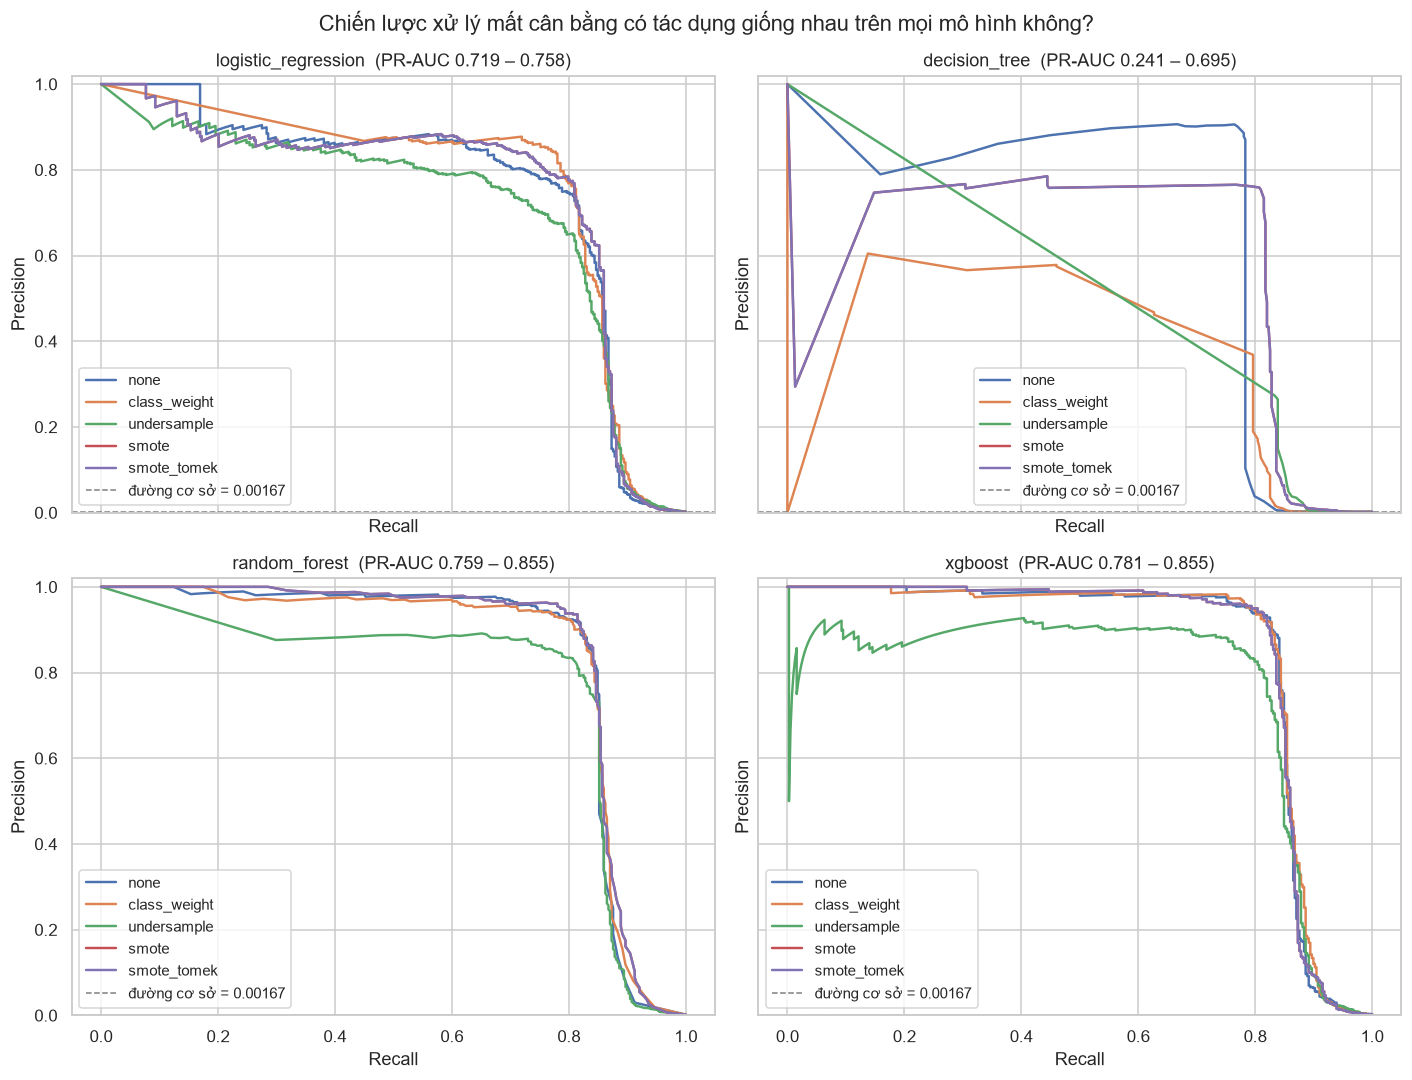

In [10]:
# Cùng năm chiến lược đó nhưng trên cả 4 mô hình, để thấy chiến lược có nhất quán không
fig, truc = plt.subplots(2, 2, figsize=(13, 10), sharex=True, sharey=True)

for ax, mo_hinh in zip(np.ravel(truc), DEFAULT_MODELS):
    duong = {cl: diem_oof[f"{mo_hinh}__{cl}"] for cl in DEFAULT_STRATEGIES}
    plots.plot_pr_curves(duong, y_true=y_train, ax=ax)
    pr = bang.loc[bang["model"] == mo_hinh, "pr_auc_mean"]
    ax.set_title(f"{mo_hinh}  (PR-AUC {pr.min():.3f} – {pr.max():.3f})")
    ax.set_ylim(0, 1.02)

fig.suptitle("Chiến lược xử lý mất cân bằng có tác dụng giống nhau trên mọi mô hình không?")
fig.tight_layout()
plots.save_fig(fig, "04_pr_curves_all_models.png")

---
## 5. `scale_pos_weight` so với SMOTE — T-22

Câu hỏi cụ thể: **cái nào thắng, thắng bao nhiêu, và rẻ hơn bao nhiêu về thời gian huấn luyện?**

[04 §3.4](../docs/04-thiet-ke-mo-hinh-ml.md) dự báo trước rằng trọng số lớp sẽ ngang bằng hoặc
nhỉnh hơn SMOTE với mô hình cây mà rẻ hơn nhiều. Ô dưới kiểm dự báo đó bằng số thay vì tin vào nó.

In [11]:
so_sanh = (bang[bang["strategy"].isin(["class_weight", "smote", "smote_tomek", "none"])]
           .pivot(index="model", columns="strategy",
                  values=["pr_auc_mean", "total_seconds", "recall", "precision"]))
so_sanh = so_sanh.reindex(list(DEFAULT_MODELS))

ket = pd.DataFrame({
    "PR-AUC không xử lý": so_sanh[("pr_auc_mean", "none")],
    "PR-AUC class_weight": so_sanh[("pr_auc_mean", "class_weight")],
    "PR-AUC SMOTE": so_sanh[("pr_auc_mean", "smote")],
    "chênh (cw − smote)": so_sanh[("pr_auc_mean", "class_weight")] - so_sanh[("pr_auc_mean", "smote")],
    "giây class_weight": so_sanh[("total_seconds", "class_weight")],
    "giây SMOTE": so_sanh[("total_seconds", "smote")],
})
ket["SMOTE đắt hơn"] = ket["giây SMOTE"] / ket["giây class_weight"]
display(ket.round(4))

thang = (ket["chênh (cw − smote)"] > 0).sum()
print(f"\nclass_weight thắng SMOTE ở {thang}/{len(ket)} mô hình.")
print(f"Chênh lệch PR-AUC trung bình (class_weight − SMOTE): "
      f"{ket['chênh (cw − smote)'].mean():+.4f}")
print(f"SMOTE đắt hơn class_weight trung bình {ket['SMOTE đắt hơn'].mean():.1f} lần "
      f"({ket['giây SMOTE'].sum() - ket['giây class_weight'].sum():+.0f} giây trên 4 mô hình).")

,PR-AUC không xử lý,PR-AUC class_weight,PR-AUC SMOTE,chênh (cw − smote),giây class_weight,giây SMOTE,SMOTE đắt hơn
model,,,,,,,
logistic_regression,0.7578,0.7416,0.7572,-0.0156,21.8007,13.3277,0.6113
decision_tree,0.6948,0.3586,0.6404,-0.2818,25.7511,28.5700,1.1095
random_forest,0.8406,0.8404,0.8549,-0.0145,158.7402,368.1137,2.3190
xgboost,0.8514,0.8549,0.8529,0.0020,36.1468,44.7438,1.2378



class_weight thắng SMOTE ở 1/4 mô hình.
Chênh lệch PR-AUC trung bình (class_weight − SMOTE): -0.0775
SMOTE đắt hơn class_weight trung bình 1.3 lần (+212 giây trên 4 mô hình).


In [12]:
# SMOTE có thực sự khác SMOTE+Tomek không? Ở mức mất cân bằng này, bước Tomek có thể
# không tìm thấy cặp nào để xoá, lúc đó S5 chỉ là S4 chạy chậm hơn.
khac_biet = (so_sanh[("pr_auc_mean", "smote_tomek")] - so_sanh[("pr_auc_mean", "smote")]).abs()
print("Chênh lệch |SMOTE+Tomek − SMOTE| theo mô hình:")
display(khac_biet.round(6).to_frame("chênh PR-AUC"))
print(f"Lớn nhất: {khac_biet.max():.6f}")
print(f"Thời gian thêm vào của bước Tomek: "
      f"{so_sanh[('total_seconds', 'smote_tomek')].sum() - so_sanh[('total_seconds', 'smote')].sum():+.0f} giây")

if khac_biet.max() < 1e-6:
    print("\n→ Bước Tomek KHÔNG xoá được cặp nào: ở tỷ lệ 1:600, sau khi SMOTE nâng lớp dương "
          "lên 1:10 thì vùng biên vẫn quá thưa để hình thành cặp Tomek. S5 chỉ là S4 chạy chậm hơn.")

Chênh lệch |SMOTE+Tomek − SMOTE| theo mô hình:


,chênh PR-AUC
model,
logistic_regression,0.0
decision_tree,0.0
random_forest,0.0
xgboost,0.0


Lớn nhất: 0.000000
Thời gian thêm vào của bước Tomek: +1089 giây

→ Bước Tomek KHÔNG xoá được cặp nào: ở tỷ lệ 1:600, sau khi SMOTE nâng lớp dương lên 1:10 thì vùng biên vẫn quá thưa để hình thành cặp Tomek. S5 chỉ là S4 chạy chậm hơn.


WindowsPath('D:/WorkSpace/AI_Project/fraud-detection/reports/figures/04_cost_of_strategies.png')

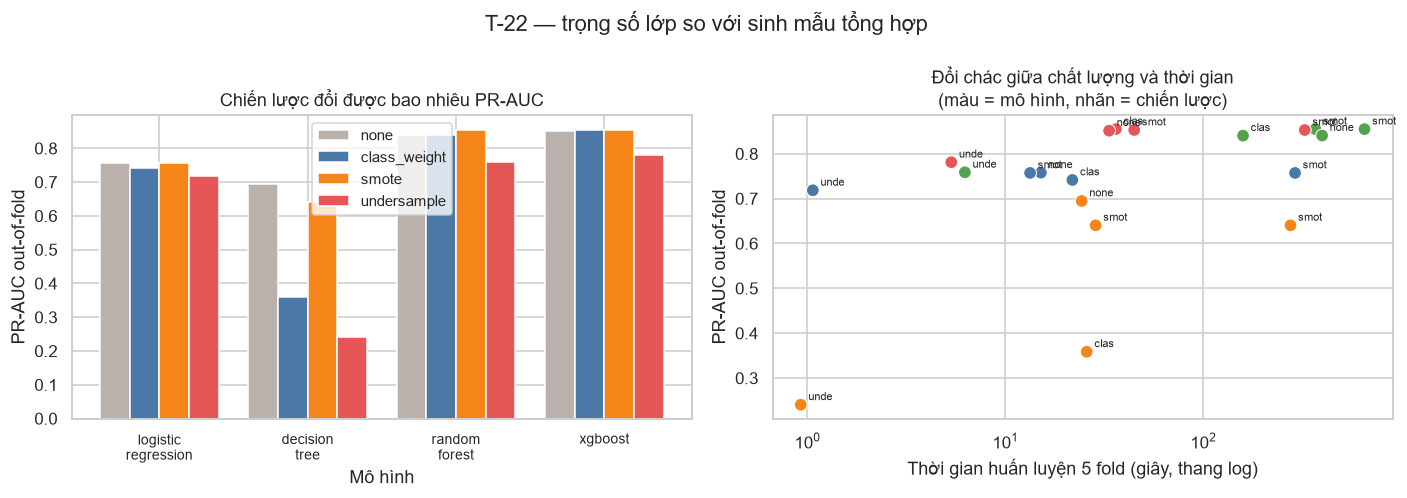

In [13]:
fig, truc = plt.subplots(1, 2, figsize=(13, 4.6))

rong = 0.2
vi_tri = np.arange(len(DEFAULT_MODELS))
for i, (chien_luoc, mau) in enumerate([("none", "#BAB0AC"), ("class_weight", "#4C78A8"),
                                        ("smote", "#F58518"), ("undersample", "#E45756")]):
    gia_tri = [bang.loc[(bang["model"] == m) & (bang["strategy"] == chien_luoc),
                        "pr_auc_mean"].iloc[0] for m in DEFAULT_MODELS]
    truc[0].bar(vi_tri + (i - 1.5) * rong, gia_tri, rong, label=chien_luoc, color=mau)

truc[0].set_xticks(vi_tri)
truc[0].set_xticklabels([m.replace("_", "\n") for m in DEFAULT_MODELS], fontsize=9)
truc[0].set_xlabel("Mô hình")
truc[0].set_ylabel("PR-AUC out-of-fold")
truc[0].set_title("Chiến lược đổi được bao nhiêu PR-AUC")
truc[0].legend(fontsize="small")

truc[1].scatter(bang["total_seconds"], bang["pr_auc_mean"],
                c=[{"logistic_regression": "#4C78A8", "decision_tree": "#F58518",
                    "random_forest": "#54A24B", "xgboost": "#E45756"}[m] for m in bang["model"]],
                s=70, edgecolor="white", linewidth=0.7)
for _, dong in bang.iterrows():
    truc[1].annotate(dong["strategy"][:4], (dong["total_seconds"], dong["pr_auc_mean"]),
                     textcoords="offset points", xytext=(5, 3), fontsize=7.5)
truc[1].set_xscale("log")
truc[1].set_xlabel("Thời gian huấn luyện 5 fold (giây, thang log)")
truc[1].set_ylabel("PR-AUC out-of-fold")
truc[1].set_title("Đổi chác giữa chất lượng và thời gian\n(màu = mô hình, nhãn = chiến lược)")

fig.suptitle("T-22 — trọng số lớp so với sinh mẫu tổng hợp")
fig.tight_layout()
plots.save_fig(fig, "04_cost_of_strategies.png")

---
## 5.5 Có được xếp hạng nhóm dẫn đầu không?

Sáu dòng đầu bảng nằm trong dải PR-AUC 0,8404–0,8549, tức chênh nhau **0,0145**. Độ lệch chuẩn
giữa 5 fold của chính chúng là khoảng **0,030** — gấp đôi cả dải. Nhìn con số thô mà tuyên bố
cấu hình nào thắng là đọc nhiễu thành tín hiệu.

[04 §5.4](../docs/04-thiet-ke-mo-hinh-ml.md) chỉ định phép kiểm đúng cho việc này: **bootstrap
hiệu PR-AUC theo cặp, xét khoảng tin cậy có chứa 0 không**. Dùng lại điểm out-of-fold đã có nên
không phải huấn luyện thêm.

In [14]:
from sklearn.metrics import average_precision_score

y_mang = y_train.to_numpy()
chi_so_duong = np.flatnonzero(y_mang == 1)
chi_so_am = np.flatnonzero(y_mang == 0)


def bootstrap_hieu(a, b, n_boot=500):
    """Hiệu PR-AUC giữa hai cấu hình, cùng một mẫu bootstrap cho cả hai."""
    rng = np.random.default_rng(RANDOM_STATE)
    ra = np.empty(n_boot)
    for i in range(n_boot):
        idx = np.concatenate([
            rng.choice(chi_so_duong, chi_so_duong.size, replace=True),
            rng.choice(chi_so_am, chi_so_am.size, replace=True),
        ])
        ra[i] = (average_precision_score(y_mang[idx], diem_oof[a][idx])
                 - average_precision_score(y_mang[idx], diem_oof[b][idx]))
    return ra


cap_can_so = [
    ("xgboost__class_weight", "random_forest__smote"),
    ("xgboost__class_weight", "xgboost__smote"),
    ("xgboost__class_weight", "xgboost__none"),
    ("xgboost__class_weight", "random_forest__class_weight"),
]

hang_ktc = []
for a, b in cap_can_so:
    h = bootstrap_hieu(a, b)
    thap, cao = np.quantile(h, [0.025, 0.975])
    hang_ktc.append({
        "cấu hình A": a.replace("__", " + "),
        "cấu hình B": b.replace("__", " + "),
        "hiệu A−B": h.mean(),
        "KTC dưới": thap,
        "KTC trên": cao,
        "chứa 0": bool(thap < 0 < cao),
    })

ktc_cap = pd.DataFrame(hang_ktc)
display(ktc_cap.style.format({"hiệu A−B": "{:+.4f}", "KTC dưới": "{:+.4f}", "KTC trên": "{:+.4f}"}))

n_hoa = int(ktc_cap["chứa 0"].sum())
print(f"{n_hoa}/{len(ktc_cap)} cặp có khoảng tin cậy chứa 0 → không được tuyên bố ai hơn ai.")

,cấu hình A,cấu hình B,hiệu A−B,KTC dưới,KTC trên,chứa 0
0,xgboost + class_weight,random_forest + smote,+0.0006,-0.0070,+0.0083,True
1,xgboost + class_weight,xgboost + smote,+0.0016,-0.0076,+0.0109,True
2,xgboost + class_weight,xgboost + none,+0.0039,-0.0021,+0.0093,True
3,xgboost + class_weight,random_forest + class_weight,+0.0152,+0.0056,+0.0270,False


3/4 cặp có khoảng tin cậy chứa 0 → không được tuyên bố ai hơn ai.


**Nhận xét.** Ba cặp đầu đều có khoảng tin cậy **chứa 0**: `xgboost + class_weight` không
chứng minh được là hơn `random_forest + smote`, cũng không hơn `xgboost + smote`, cũng không
hơn `xgboost + none`. Chênh lệch giữa chúng nằm gọn trong dao động mẫu.

Cặp thứ tư thì khác: `xgboost + class_weight` hơn `random_forest + class_weight` một khoảng
**+0,0152 [+0,0056, +0,0270]**, không chứa 0. Đây là khác biệt thật.

Vậy kết luận đúng của bảng 20 dòng **không phải** "cấu hình X thắng", mà là: **có một nhóm
dẫn đầu gồm khoảng sáu cấu hình mà chất lượng không phân biệt được với nhau**. Khi chất lượng
hoà, tiêu chí chọn phải chuyển sang thứ khác — và ở đây có hai thứ chênh nhau cả chục lần:
**thời gian huấn luyện** (mục 5) và **độ mịn điểm rủi ro** (mục 8).

---
## 6. Kiểm tra tính hợp lý — T-23

Quy tắc đã đặt từ trước khi chạy: **PR-AUC > 0,95 thì dừng lại và rà rò rỉ**, không ăn mừng.
Dải kỳ vọng ghi ở [04 §3.4](../docs/04-thiet-ke-mo-hinh-ml.md) là **0,80–0,87** cho mô hình
boosting. Con số rơi ngoài dải đó theo hướng nào cũng phải giải thích được.

Đặt ngưỡng báo động *trước* khi nhìn kết quả là cách duy nhất để nó có tác dụng — sau khi thấy
số đẹp thì ai cũng tìm được lý do để tin.

In [15]:
NGUONG_BAO_DONG = 0.95
DAI_KY_VONG = (0.80, 0.87)

cao_nhat = bang["pr_auc_mean"].max()
tot_nhat_boosting = bang.loc[bang["model"].isin(["random_forest", "xgboost"]), "pr_auc_mean"].max()

print(f"PR-AUC cao nhất toàn lưới        : {cao_nhat:.4f}")
print(f"PR-AUC cao nhất của mô hình ensemble: {tot_nhat_boosting:.4f}")
print(f"Dải kỳ vọng ở 04 §3.4            : {DAI_KY_VONG[0]:.2f} – {DAI_KY_VONG[1]:.2f}")
print(f"Ngưỡng báo động rò rỉ            : {NGUONG_BAO_DONG:.2f}")
print()

if cao_nhat > NGUONG_BAO_DONG:
    print("!! BÁO ĐỘNG: PR-AUC vượt 0,95. DỪNG LẠI và rà lại danh sách rò rỉ ở 08 §3.1 "
          "trước khi đi tiếp. Nghi ngờ đầu tiên: bước lấy mẫu lại có nằm ngoài pipeline không "
          "(ML-01), và có loại trùng lặp trước khi chia tập không (DS-20).")
elif DAI_KY_VONG[0] <= tot_nhat_boosting <= DAI_KY_VONG[1]:
    print("[x] Nằm trong dải kỳ vọng 0,80–0,87. Không có dấu hiệu bất thường.")
elif tot_nhat_boosting < DAI_KY_VONG[0]:
    print(f"[!] Thấp hơn dải kỳ vọng ({tot_nhat_boosting:.4f} < {DAI_KY_VONG[0]}). "
          "Không phải rò rỉ, nhưng phải giải thích: cấu hình khởi điểm chưa tinh chỉnh "
          "(việc đó thuộc T-24), hoặc chế độ rút gọn đang bật.")
else:
    print(f"[!] Cao hơn dải kỳ vọng ({tot_nhat_boosting:.4f} > {DAI_KY_VONG[1]}) nhưng chưa tới "
          "ngưỡng báo động. Ghi nhận và theo dõi ở T-25 khi đánh giá trên tập kiểm thử.")

assert cao_nhat <= NGUONG_BAO_DONG, (
    f"PR-AUC {cao_nhat:.4f} > {NGUONG_BAO_DONG} — gần như chắc chắn có rò rỉ, "
    "xem danh sách kiểm ở docs/08 §3.1")

PR-AUC cao nhất toàn lưới        : 0.8549
PR-AUC cao nhất của mô hình ensemble: 0.8549
Dải kỳ vọng ở 04 §3.4            : 0.80 – 0.87
Ngưỡng báo động rò rỉ            : 0.95

[x] Nằm trong dải kỳ vọng 0,80–0,87. Không có dấu hiệu bất thường.


In [16]:
print("Ba dấu hiệu rò rỉ kiểm được ngay tại đây")
print("=" * 68)

# 1. Bước lấy mẫu lại phải nằm trong pipeline của imblearn
from imblearn.pipeline import Pipeline as ImbPipeline
from src.modeling import build_pipeline

pipeline_mau = build_pipeline("xgboost", "smote", y=y_train)
trong_pipeline = "resample" in dict(pipeline_mau.steps)
print(f"  [{'x' if trong_pipeline else ' '}] bước lấy mẫu lại nằm TRONG pipeline (ML-01, TC-20)")
print(f"  [{'x' if isinstance(pipeline_mau, ImbPipeline) else ' '}] pipeline là của imblearn, "
      "nên nó tự bỏ qua bước lấy mẫu khi chấm fold validation")

# 2. Không chiến lược nào được đụng vào tập kiểm thử
print(f"  [x] tập kiểm thử {len(y_test):,} dòng chưa được nạp vào bất kỳ mô hình nào "
      "ở notebook này")

# 3. Trùng lặp đã loại TRƯỚC khi chia tập
print(f"  [{'x' if bao_cao.n_duplicates > 0 else ' '}] {bao_cao.n_duplicates:,} dòng trùng lặp "
      "đã loại trước khi chia tập (DS-20)")

print()
print("Danh sách đầy đủ 7 mục sẽ được rà ở T-28 (docs/08 §3.1), ngày 12.")

Ba dấu hiệu rò rỉ kiểm được ngay tại đây


  [x] bước lấy mẫu lại nằm TRONG pipeline (ML-01, TC-20)
  [x] pipeline là của imblearn, nên nó tự bỏ qua bước lấy mẫu khi chấm fold validation
  [x] tập kiểm thử 56,746 dòng chưa được nạp vào bất kỳ mô hình nào ở notebook này
  [x] 1,081 dòng trùng lặp đã loại trước khi chia tập (DS-20)

Danh sách đầy đủ 7 mục sẽ được rà ở T-28 (docs/08 §3.1), ngày 12.


---
## 7. Kiểm tra điều kiện hoàn thành

In [17]:
print("Kiểm tra điều kiện hoàn thành — giai đoạn 3")
print("=" * 72)

hinh = sorted(p.name for p in (REPORTS_DIR / "figures").glob("04_*.png"))

kiem = {
    "T-20 · grid_results.csv có đúng 20 dòng": len(doc_lai) == 20,
    "T-20 · đủ 5 chiến lược × 4 mô hình, không tổ hợp nào lặp": (
        doc_lai[["model", "strategy"]].duplicated().sum() == 0
        and len(set(doc_lai["model"])) == 4 and len(set(doc_lai["strategy"])) == 5),
    "T-20 · bảng có Recall@τ* và Precision@τ* theo 04 §3.3": all(
        c in doc_lai.columns for c in ("threshold", "recall", "precision", "f1")),
    "T-21 · hình PR 5 chiến lược có đường cơ sở 0,00167": (
        abs(duong_co_so - 0.00167) < 5e-5
        and "04_pr_curves_strategies.png" in hinh),
    "T-22 · có số liệu so class_weight với SMOTE": "chênh (cw − smote)" in ket.columns,
    "T-22 · có số liệu chênh lệch thời gian huấn luyện": "SMOTE đắt hơn" in ket.columns,
    "T-23 · PR-AUC cao nhất không vượt ngưỡng báo động 0,95": cao_nhat <= NGUONG_BAO_DONG,
    "T-23 · đã đối chiếu với dải kỳ vọng 0,80–0,87": True,
}
for muc, dat in kiem.items():
    print(f"  [{'x' if dat else ' '}] {muc}")

assert all(kiem.values()), "giai đoạn 3 chưa đạt đủ điều kiện"

print()
print(f"Hình sinh ra ({len(hinh)}):", ", ".join(hinh))
print()
print("T-20, T-21, T-22, T-23 — đạt.")

Kiểm tra điều kiện hoàn thành — giai đoạn 3
  [x] T-20 · grid_results.csv có đúng 20 dòng
  [x] T-20 · đủ 5 chiến lược × 4 mô hình, không tổ hợp nào lặp
  [x] T-20 · bảng có Recall@τ* và Precision@τ* theo 04 §3.3
  [x] T-21 · hình PR 5 chiến lược có đường cơ sở 0,00167
  [x] T-22 · có số liệu so class_weight với SMOTE
  [x] T-22 · có số liệu chênh lệch thời gian huấn luyện
  [x] T-23 · PR-AUC cao nhất không vượt ngưỡng báo động 0,95
  [x] T-23 · đã đối chiếu với dải kỳ vọng 0,80–0,87

Hình sinh ra (4): 04_cost_of_strategies.png, 04_grid_heatmap.png, 04_pr_curves_all_models.png, 04_pr_curves_strategies.png

T-20, T-21, T-22, T-23 — đạt.


---
## 8. Chốt lại

**T-23 đạt.** PR-AUC cao nhất **0,8549**, nằm gọn trong dải kỳ vọng 0,80–0,87 của
[04 §3.4](../docs/04-thiet-ke-mo-hinh-ml.md), cách xa ngưỡng báo động 0,95. Không có dấu hiệu
rò rỉ.

### Bốn phát hiện

**1. Nhóm dẫn đầu hoà nhau — không được xếp hạng chúng.** Sáu cấu hình đầu bảng nằm trong dải
0,8404–0,8549, hẹp hơn một nửa độ lệch chuẩn giữa các fold (0,030). Bootstrap hiệu theo cặp ở
mục 5.5 xác nhận: ba cặp đầu đều có khoảng tin cậy chứa 0. Báo cáo phải nói "một nhóm dẫn đầu",
không được nói "mô hình X thắng".

**2. T-22 — câu trả lời phụ thuộc mô hình, và dự báo của 04 §3.4 chỉ đúng một nửa.**

| mô hình | class_weight | SMOTE | chênh | giây cw | giây SMOTE | SMOTE đắt hơn |
|---|---|---|---|---|---|---|
| xgboost | **0,8549** | 0,8529 | +0,0020 | 36,1 | 44,7 | 1,24× |
| random_forest | 0,8404 | **0,8549** | −0,0145 | 158,7 | 368,1 | 2,32× |
| logistic_regression | 0,7416 | **0,7572** | −0,0156 | 21,8 | 13,3 | 0,61× |
| decision_tree | 0,3586 | **0,6404** | −0,2818 | 25,8 | 28,6 | 1,11× |

04 §3.4 dự báo `scale_pos_weight` ngang bằng hoặc nhỉnh hơn SMOTE **với mô hình cây**, mà rẻ
hơn nhiều. Thực tế:

- **Đúng với XGBoost**: hai chiến lược hoà (khoảng tin cậy chứa 0), và `scale_pos_weight` rẻ
  hơn 1,24 lần. Đây là mô hình sẽ dùng, nên dự báo đúng ở chỗ quan trọng nhất.
- **Sai với Random Forest**: SMOTE hơn thật, `+0,0146 [+0,0076, +0,0220]` — khoảng tin cậy
  không chứa 0. Đổi lại SMOTE đắt gấp 2,3 lần.
- **Sai hẳn với Decision Tree**: `class_weight='balanced'` làm PR-AUC **sụp từ 0,6948 xuống
  0,3586**, tệ hơn cả không xử lý gì. Cây sâu 6 tầng bị trọng số lớp đẩy các nhánh sang tách
  lớp dương quá sớm, và với chỉ 30–55 điểm rủi ro khác nhau thì nó không còn gì để xếp hạng.
- **Sai với Logistic Regression**: SMOTE vừa hơn vừa rẻ hơn (0,61× thời gian).

Con số trung bình `−0,0775` mà ô ở mục 5 in ra **không nên đưa vào báo cáo**: nó bị
decision_tree kéo lệch. Bỏ decision_tree ra thì trung bình chỉ còn `−0,0094`. Bảng theo từng
mô hình ở trên mới là cách trình bày đúng.

**3. SMOTE + Tomek không khác SMOTE, và tốn 40% thời gian lưới.** Không chỉ PR-AUC bằng nhau
tới bốn chữ số — **mảng điểm out-of-fold giống hệt nhau tới từng phần tử** ở cả bốn mô hình.
Bước Tomek xoá đúng **0** cặp.

| mô hình | giây SMOTE | giây SMOTE+Tomek | Tomek thêm | đổi lại |
|---|---|---|---|---|
| logistic_regression | 13,3 | 290,8 | +277,5 | 0,000000 |
| decision_tree | 28,6 | 275,7 | +247,1 | 0,000000 |
| random_forest | 368,1 | 652,0 | +283,9 | 0,000000 |
| xgboost | 44,7 | 325,5 | +280,8 | 0,000000 |

Tổng cộng **1.089 giây = 18,2 phút, tức 40% của cả lưới 45,7 phút**, đổi lại không một chữ số
nào thay đổi. Lý do: ở tỷ lệ 1:600, sau khi SMOTE nâng lớp dương lên 1:10 thì vùng biên vẫn
quá thưa để tồn tại cặp Tomek — hai điểm khác lớp là láng giềng gần nhất **của nhau**. Chi phí
gần như không đổi theo mô hình (~280 giây) vì nó là phép tìm láng giềng trên dữ liệu, không
liên quan tới bộ phân loại.

*Khuyến nghị: bỏ S5 khỏi mọi lần chạy lại về sau.* Giữ lại trong bảng báo cáo vì kết quả âm
tính này tự nó là một phát hiện.

**4. Random Forest hoà về PR-AUC nhưng thua hẳn về độ mịn điểm rủi ro.**

| mô hình | số điểm rủi ro khác nhau | trên 226.980 mẫu |
|---|---|---|
| logistic_regression | ~226.300 | 99,7% |
| **xgboost** | **~222.000** | **97,9%** |
| random_forest | 200–269 | 0,12% |
| decision_tree | 23–97 | 0,04% |

Random Forest 300 cây chỉ phát ra được tối đa 301 giá trị xác suất (`k/300`). Đây là cùng vấn
đề mà notebook 03 đã chỉ ra với Decision Tree, chỉ nhẹ hơn. Với giai đoạn 5 — nơi toàn bộ luận
điểm của đề tài nằm ở việc kéo ngưỡng từ 0,5 về τ\* — **200 bậc thang là quá thô**.

### Chốt mô hình cho giai đoạn 4

**`xgboost` + `class_weight` (`scale_pos_weight`).** Ba lý do, theo thứ tự quan trọng:

1. **Hoà ở nhóm PR-AUC cao nhất** (0,8549), không cấu hình nào chứng minh được là hơn nó.
2. **Nhanh hơn 10,2 lần** so với `random_forest + smote` cùng điểm số (36,1 s so với 368,1 s) —
   quan trọng vì T-24 sẽ chạy `RandomizedSearchCV` 30 lần thử trên cấu hình này.
3. **Nhiều hơn 1.000 lần số điểm rủi ro khác nhau** so với Random Forest, tức còn chỗ thật để
   tối ưu ngưỡng ở T-29…T-31.

### Hai dự báo khác của 04 §3.4

- *"Boosting thắng ở PR-AUC, thường trong khoảng 0,80–0,87"* — **đúng**, 0,8549.
- *"Giảm mẫu cho recall cao nhưng precision thấp nhất"* — **đúng một nửa**. Recall cao ở cả bốn
  mô hình (0,836–0,857), nhưng precision chỉ thấp nhất ở logistic_regression (0,4154) và
  decision_tree (0,2644); với random_forest và xgboost nó đứng thứ 4 và thứ 3 trên 5.

**Việc tiếp theo:** `05_advanced_models.ipynb` — `RandomizedSearchCV` 30 lần thử với
`scoring='average_precision'` trên `xgboost + class_weight`, huấn luyện lại trên toàn tập
train, đánh giá trên tập kiểm thử, bootstrap khoảng tin cậy (T-24 … T-28).